# Step:1 **Loading the Dataset**

In [1]:
import pandas as pd

file_path = "/kaggle/input/datasets/atharvaingle/crop-recommendation-dataset/Crop_recommendation.csv"

df = pd.read_csv(file_path)

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# **Step 2: Understand the Dataset**

## **Display the first few rows**

In [2]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## **Display the last few rows**

In [3]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


## **Display the dataset shape**

In [4]:
rows, cols = df.shape

print("Rows :", rows)
print("Columns :", cols)

Rows : 2200
Columns : 8


## **Check the column names**

In [5]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

## **Check data types**

In [6]:
df.dtypes

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

## **Check dataset information**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


## **Statistical Summary**

In [8]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


## **Check for missing values**

In [9]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

## **Check Duplicate Records**

In [10]:
df.duplicated().sum()

np.int64(0)

## **View a few random rows**

In [11]:
df.sample(5)

,N,P,K,temperature,humidity,ph,rainfall,label
1501,7,144,197,23.849401,94.348150,6.133221,114.051249,apple
1820,34,6,30,27.082825,97.001555,5.948343,171.757554,coconut
688,39,37,15,28.997315,83.789115,6.821747,59.844992,mungbean
1739,50,47,48,24.636769,90.619643,6.712772,218.229919,papaya
632,29,36,25,28.285115,88.439398,7.130279,48.566902,mungbean


## **Number of Crop Classes**

In [12]:
df['label'].nunique()

22

## **List Crop Names**

In [13]:
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

## **Count Samples per Crop**

In [14]:
df['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

# **Step 3: Exploratory Data Analysis (EDA)**

## **Distribution of Crop Classes**

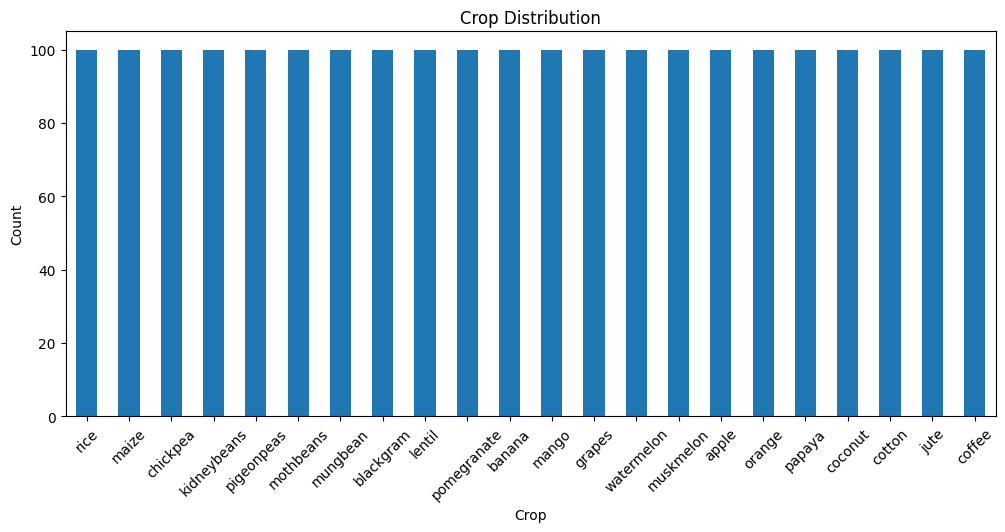

In [15]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', figsize=(12,5))

plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## **Correlation Matrix**

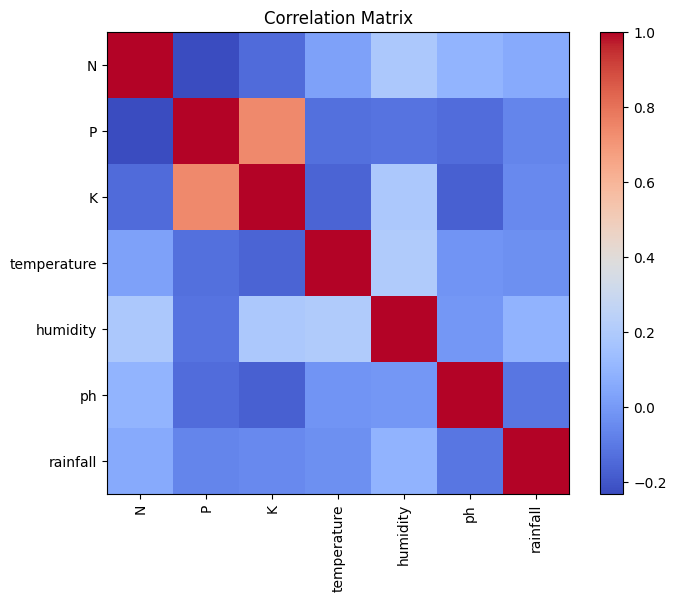

In [16]:
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()

## **Histograms**

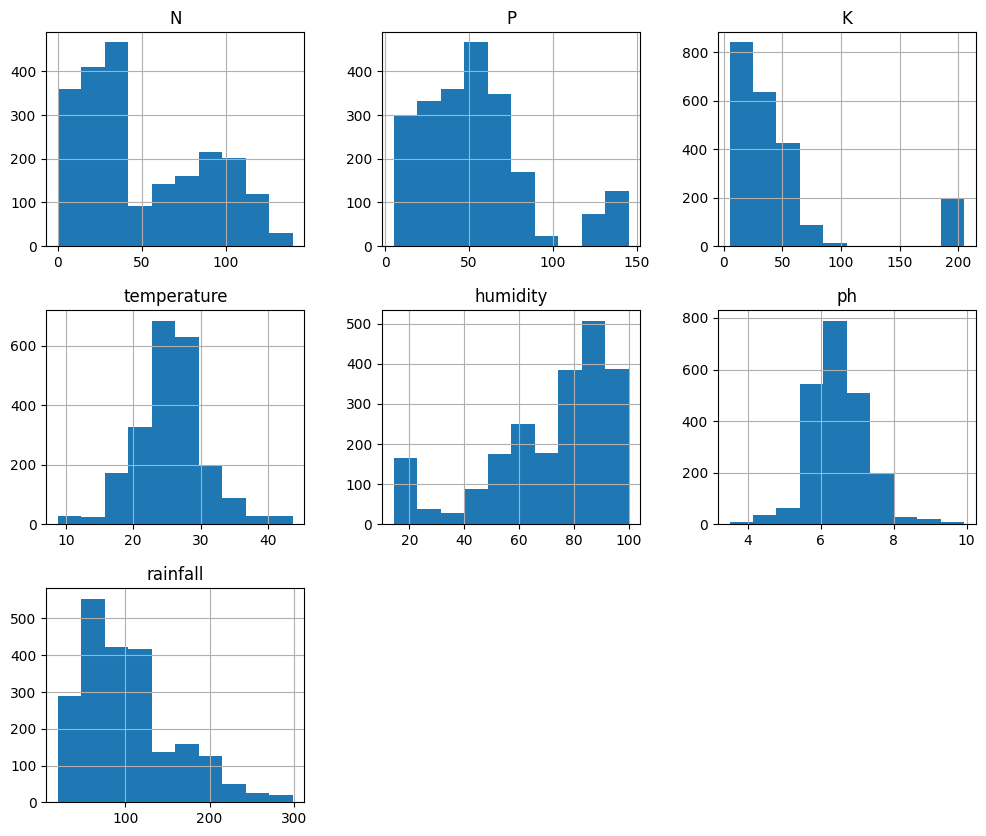

In [17]:
df.hist(figsize=(12,10))
plt.show()

## **Step 4: Data Preprocessing**

In [18]:
X = df.drop('label', axis=1)

y = df['label']

## **Step 5: Encode the Target Variable**

## **Check unique crop names**

In [19]:
print(y.unique())

['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


## **Encode the labels**

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

## **Verify the encoding**

In [21]:
print(y[:10])

[20 20 20 20 20 20 20 20 20 20]


## **You can also see the mapping:**

In [22]:
crop_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print(crop_mapping)

{'apple': np.int64(0), 'banana': np.int64(1), 'blackgram': np.int64(2), 'chickpea': np.int64(3), 'coconut': np.int64(4), 'coffee': np.int64(5), 'cotton': np.int64(6), 'grapes': np.int64(7), 'jute': np.int64(8), 'kidneybeans': np.int64(9), 'lentil': np.int64(10), 'maize': np.int64(11), 'mango': np.int64(12), 'mothbeans': np.int64(13), 'mungbean': np.int64(14), 'muskmelon': np.int64(15), 'orange': np.int64(16), 'papaya': np.int64(17), 'pigeonpeas': np.int64(18), 'pomegranate': np.int64(19), 'rice': np.int64(20), 'watermelon': np.int64(21)}


## **Step 6: Split the Dataset**

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## **Check the shapes**

In [24]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1760, 7)
X_test : (440, 7)
y_train: (1760,)
y_test : (440,)


# **Step 7: Train Your First Model**

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

##  **Step 8: Make Predictions**

In [26]:
y_pred = rf_model.predict(X_test)

## **Step 9: Evaluate the Model**

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9954545454545455


## **Classification Report**

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    

## **Confusion Matrix**

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 19  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0

## **Display Feature Importance**

       Feature  Importance
6     rainfall    0.230184
4     humidity    0.224227
2            K    0.175393
1            P    0.150850
0            N    0.096363
3  temperature    0.072375
5           ph    0.050608


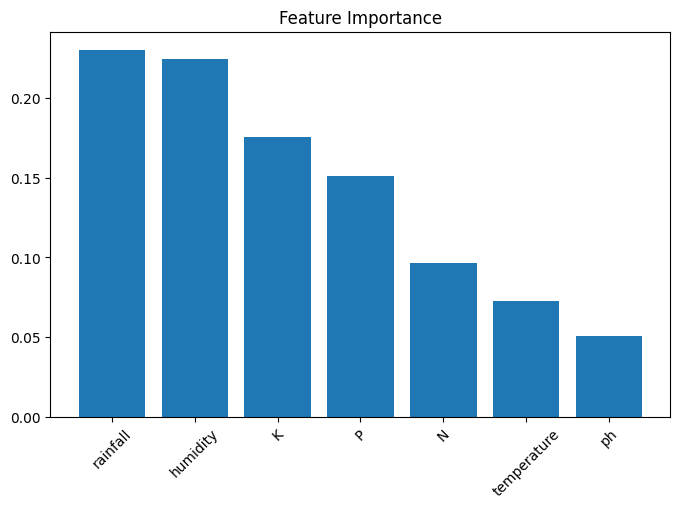

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(8,5))
plt.bar(feature_importance['Feature'],
        feature_importance['Importance'])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

## **Test the Model with New Data**

In [31]:
import pandas as pd

sample = pd.DataFrame({
    'N': [90],
    'P': [42],
    'K': [43],
    'temperature': [20.87],
    'humidity': [82.0],
    'ph': [6.5],
    'rainfall': [202]
})

prediction = rf_model.predict(sample)

crop = le.inverse_transform(prediction)

print("Recommended Crop:", crop[0])

Recommended Crop: rice


## **Predict Confidence**

In [32]:
probability = rf_model.predict_proba(sample)

confidence = probability.max() * 100

print("Recommended Crop:", crop[0])
print(f"Confidence: {confidence:.2f}%")

Recommended Crop: rice
Confidence: 90.00%


## **Make It More Useful for KisanMitra**

In [33]:
prediction = rf_model.predict(sample)
crop = le.inverse_transform(prediction)[0]

confidence = rf_model.predict_proba(sample).max() * 100

result = {
    "Recommended Crop": crop,
    "Confidence": f"{confidence:.2f}%"
}

print(result)

{'Recommended Crop': 'rice', 'Confidence': '90.00%'}


## **Save the Model**

In [34]:
import joblib

joblib.dump(rf_model, "crop_recommendation_model.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

## **Verify the Files**

In [35]:
import os

print(os.listdir("/kaggle/working"))

['label_encoder.pkl', 'crop_recommendation_model.pkl', '.virtual_documents']


## **Test That the Saved Model Works**

In [36]:
import joblib

# Load the saved model
model = joblib.load("/kaggle/working/crop_recommendation_model.pkl")

# Load the label encoder
encoder = joblib.load("/kaggle/working/label_encoder.pkl")

In [37]:
import pandas as pd

sample = pd.DataFrame({
    'N': [90],
    'P': [42],
    'K': [43],
    'temperature': [20.87],
    'humidity': [82],
    'ph': [6.5],
    'rainfall': [202]
})

prediction = model.predict(sample)

crop = encoder.inverse_transform(prediction)

print("Recommended Crop:", crop[0])

Recommended Crop: rice
